#**CHAPTER 10.GENETIC ALGORITHMS**
---

##REFERENCE

https://chatgpt.com/share/69a9e910-e650-8012-918a-6e6473b59e6a

##0.CONTEXT

*Introduction*

Chapter 10 is the point in ML & AI 101 where we briefly step “outside” a single fixed model and instead study a mechanism for *searching* over models. Up to this point, the notebook sequence has been teaching you how training works when the architecture is decided in advance: you pick a KNN rule, a dense network, a CNN, an RNN/LSTM, a transformer block, or a generative system (GAN/diffusion), and then you tune parameters by some version of gradient descent. Genetic Algorithms (GAs) shift the lens. The core idea is not “learn the weights of one network,” but “evolve the *shape* of the network (and sometimes its hyperparameters) by iteratively selecting better candidates.” In other words, instead of optimizing a continuous vector of weights by gradients, we optimize a discrete design space of architectures by a population-based search rule.

Mechanically, a GA is a loop that repeatedly performs three operations: **variation**, **selection**, and **inheritance**. Variation creates candidate designs (genomes) by random sampling, mutation, and crossover. Selection evaluates candidates with a *fitness function* and keeps the best ones. Inheritance generates a new population biased toward the “genetic material” of high-fitness candidates. The notebook uses this framework in a deliberately small, fully synthetic setting where everything is visible: a simple 2D classification dataset (Gaussian clusters) and tiny MLP architectures that satisfy the pedagogical constraints (no more than three hidden layers, small hidden widths, simple activations, optional dropout). Because the data is synthetic and deterministic, you can focus on the mechanics of the search rather than the messiness of real-world datasets.

This chapter is also a bridge in the book’s conceptual arc. Earlier chapters introduced inductive biases (locality in CNNs, recurrence for temporal structure, attention for global context, message passing for relational structure). The GA chapter introduces a meta-level perspective: sometimes you do not know in advance which inductive bias strength or architectural capacity is “right,” and you want a systematic search procedure that tries alternatives. Here the GA is not magic; it is an explicit, inspectable algorithm that makes tradeoffs. It can explore discrete choices (layer count, hidden widths, activation types, dropout) that are awkward for gradient descent. But it pays for that flexibility with expensive evaluation, since every candidate must be trained (even briefly) to estimate its fitness.

A major learning objective of this notebook is to see clearly the separation between **training** and **inference** in a meta-optimization setting. Inside the GA, there is an “inner loop” where each candidate network is trained for a small number of steps to obtain a measurable score (accuracy plus a small complexity penalty). That inner-loop training is ordinary supervised learning. Around it, there is an “outer loop” where the GA updates the population based on those scores. That outer loop is not gradient descent; it is a selection-and-variation process that changes which architectures exist at all. After evolution is complete, the notebook trains the best evolved architecture more cleanly and then demonstrates inference on a new synthetic point, reinforcing that an architecture discovered by meta-optimization still behaves like an ordinary model at inference time.

Visualization is central in this chapter because it makes the GA’s behavior legible. You will see fitness trajectories across generations (best vs average), which illustrates whether the search is making progress or stagnating. You will also see decision boundaries for a baseline architecture versus the evolved architecture. Those boundaries provide a concrete interpretability lens: they show how architecture capacity and training affect the shape of the classifier’s partition of the input space. This connects directly to the theme of ML & AI 101: models are not mysterious; they are explicit computational mechanisms whose behavior can be understood by watching their losses, their predictions, and their geometric decisions.

Finally, because this is pre-governance, the notebook intentionally avoids policy framing and focuses purely on mechanism. The key takeaway you should be aiming for is not “genetic algorithms are better,” but rather: **they are a different optimization tool** suited to discrete design spaces, and you can observe exactly how their selection pressure and mutation/crossover operators reshape a population of candidate architectures over time. By the end, you should be able to explain, in mechanical terms, what the genome encodes, how fitness is computed, why the outer loop can improve architectures, and what the resulting decision boundaries tell you about capacity and generalization.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, Determinism, Device, and Shared Plotting/Training Utilities**

Cell 1 establishes the notebook’s “lab environment.” Even though this chapter is about genetic algorithms, the notebook still needs a consistent experimental scaffold: deterministic randomness, a device choice (CPU or GPU), and a standard set of plotting utilities that will be reused later for visual inspection. The determinism requirements are critical here because the GA is inherently stochastic. If you cannot reproduce the same population initialization, the same mutations, and the same training mini-batches, you cannot tell whether changes in fitness come from the algorithm’s logic or from random drift. Setting `random.seed(0)`, `numpy.random.seed(0)`, and the PyTorch seeds ensures that when you rerun the notebook, you get the same evolutionary story.

The device helper is conceptually simple but important for pedagogy: it reminds you that the same computation can run on CPU or GPU, and that training cost is a real consideration in population-based methods. In GA settings, you can easily multiply training cost by the population size, so being explicit about device selection is part of understanding the mechanics and cost profile of meta-optimization.

The plotting utilities do more than “make nice pictures.” They encode the idea that every model mechanism should have a visible footprint. In this chapter, the most important visuals are (1) loss curves for inner-loop training and (2) decision boundaries that show how a network partitions the input space. Even though a GA does not optimize weights directly, it still relies on weight training to evaluate each candidate. Loss curves reveal whether those short training runs behave sensibly or are unstable. Decision boundary plots reveal the *functional form* implied by the architecture and its learned parameters.

Finally, the PyTorch helpers (`train_loop`, `evaluate`, `predict`) standardize the training and evaluation mechanics when we later train the “best evolved” model more carefully. This separation matters: the GA’s fitness evaluations are intentionally short and noisy approximations (because we must evaluate many candidates), while the later training of the chosen architecture is a more normal supervised learning workflow. Having shared helpers makes it easier to compare those contexts. Mechanically, Cell 1 is where the notebook defines how “training” will be executed and how “performance” will be measured, before any data or models exist. That order matters: you want to lock down the experimental protocol first, then apply it.

In [ ]:
# ===============================
# CELL 1
# ===============================
import os
import math
import json
import time
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

DEVICE = get_device()
print("Device:", DEVICE)

# Unified plotting style
plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Shared plotting utilities
# -------------------------------
def plot_loss_curve(losses, title="Loss Curve"):
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    plt.figure(figsize=(6, 5))
    Xn = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    yn = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)
    plt.scatter(Xn[:, 0], Xn[:, 1], c=yn, s=12)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    model.eval()
    Xn = X.detach().cpu()
    yn = y.detach().cpu()
    x_min, x_max = Xn[:, 0].min().item() - 0.5, Xn[:, 0].max().item() + 0.5
    y_min, y_max = Xn[:, 1].min().item() - 0.5, Xn[:, 1].max().item() + 0.5

    xs = torch.linspace(x_min, x_max, 250)
    ys = torch.linspace(y_min, y_max, 250)
    grid_x, grid_y = torch.meshgrid(xs, ys, indexing="xy")
    grid = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)

    with torch.no_grad():
        logits = model(grid.to(next(model.parameters()).device))
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()

    plt.figure(figsize=(6, 5))
    plt.contourf(grid_x.numpy(), grid_y.numpy(), preds.reshape(250, 250), alpha=0.35)
    plt.scatter(Xn[:, 0].numpy(), Xn[:, 1].numpy(), c=yn.numpy(), s=12)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

def show_image(img, title="Image"):
    arr = img.detach().cpu().numpy() if torch.is_tensor(img) else np.asarray(img)
    plt.figure(figsize=(4, 4))
    if arr.ndim == 2:
        plt.imshow(arr, cmap="gray")
    else:
        plt.imshow(arr)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid", max_n=16):
    imgs = images[:max_n]
    n = len(imgs)
    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(cols * 2.2, rows * 2.2))
    for i in range(n):
        ax = plt.subplot(rows, cols, i + 1)
        arr = imgs[i].detach().cpu().numpy() if torch.is_tensor(imgs[i]) else np.asarray(imgs[i])
        if arr.ndim == 2:
            ax.imshow(arr, cmap="gray")
        else:
            ax.imshow(arr)
        if labels is not None:
            ax.set_title(str(labels[i]))
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_histograms(real, fake, title="Real vs Fake"):
    r = real.detach().cpu().numpy().reshape(-1) if torch.is_tensor(real) else np.asarray(real).reshape(-1)
    f = fake.detach().cpu().numpy().reshape(-1) if torch.is_tensor(fake) else np.asarray(fake).reshape(-1)
    plt.figure(figsize=(7, 4))
    plt.hist(r, bins=40, alpha=0.6, label="real")
    plt.hist(f, bins=40, alpha=0.6, label="fake")
    plt.title(title)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

def plot_attention(matrix, title="Attention"):
    mat = matrix.detach().cpu().numpy() if torch.is_tensor(matrix) else np.asarray(matrix)
    plt.figure(figsize=(5, 4))
    plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.xlabel("Key index")
    plt.ylabel("Query index")
    plt.colorbar()
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Placeholder for non-graph chapters; kept for uniform contract.
    plt.figure(figsize=(5, 4))
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.text(0.5, 0.5, "plot_graph is a no-op in this chapter", ha="center", va="center")
    plt.axis("off")
    plt.show()

# -------------------------------
# PyTorch helpers
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs=50, batch_size=64):
    model.train()
    losses = []
    n = X.shape[0]
    for epoch in range(1, epochs + 1):
        perm = torch.randperm(n, device=X.device)
        Xb = X[perm]
        yb = y[perm]
        epoch_loss = 0.0

        for i in range(0, n, batch_size):
            xb = Xb[i:i + batch_size]
            ybatch = yb[i:i + batch_size]

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = loss_fn(logits, ybatch)
            loss.backward()
            optimizer.step()

            lval = loss.detach().item()
            losses.append(lval)
            epoch_loss += lval * xb.shape[0]

        epoch_loss /= n
        print(f"epoch {epoch:03d}/{epochs} - loss {epoch_loss:.4f}")

    return losses

@torch.no_grad()
def evaluate(model, X, y):
    model.eval()
    logits = model(X)
    preds = torch.argmax(logits, dim=1)
    acc = (preds == y).float().mean().item()
    return {"accuracy": acc}

@torch.no_grad()
def predict(model, X):
    model.eval()
    logits = model(X)
    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    return preds, probs

Device: cpu


##2.DATA GENERATIORS

###2.1.OVERVIEW

**Cell 2 — Synthetic Data and Genetic Algorithm Building Blocks (Genomes, Mutation, Crossover)**

Cell 2 defines the two ingredients that make a GA experiment possible: a deterministic synthetic dataset generator and the genetic operators that manipulate candidate solutions. On the data side, the notebook uses Gaussian clusters in 2D. This is a purposeful choice. In 2D, you can visualize everything: the data distribution, the model’s decision boundary, and the ways that boundaries succeed or fail as the architecture changes. The generator is parameterized (number of points per class, cluster centers, standard deviation), and it uses numpy only to satisfy the “synthetic-only, deterministic” constraint.

Also in Cell 2 are the utilities that make the dataset usable for learning: a deterministic train/test split and normalization computed on the training set only. Normalization is not just a best practice; it shapes the optimization geometry for gradient-based inner-loop training. If features have wildly different scales, even a well-designed architecture can train poorly in a short evaluation window. Since the GA’s fitness relies on short training runs, stable scaling is essential to get meaningful fitness signals.

The GA building blocks are the conceptual heart of the chapter. The “genome” is a compact, discrete representation of an architecture. In this notebook, it encodes: (1) number of hidden layers (1–3), (2) the hidden width of each layer (chosen from a small set), (3) activation type (e.g., ReLU or tanh), and (4) dropout level (chosen from a small set). This genome is deliberately small so you can understand exactly what the GA is searching over. Importantly, the genome is not the weights. The weights are learned during fitness evaluation, but the genome determines the *structure* of the computation graph that will be trained.

Mutation and crossover implement the “variation” step. Mutation makes small local edits: changing the number of layers, swapping a hidden size, switching activation, or adjusting dropout. Crossover mixes information from two parents: for example, combining part of one hidden-size sequence with part of another. These operators define the exploration dynamics of the search space. If mutation is too weak, the population can stagnate. If it is too strong, the population becomes random and selection cannot accumulate improvements. In this notebook, mutation probability and tournament selection size later become key knobs that shape how quickly the search improves.

Cell 2 therefore sets the stage for the rest of the notebook: it defines what “candidate solutions” look like, how they are created and modified, and how the data will provide an environment in which those candidates can be evaluated.

###2.2.CODE AND IMPLEMENTATION

In [ ]:
# ===============================
# CELL 2
# ===============================
def generate_gaussian_clusters(n_per_class=400, centers=None, std=0.65, seed=0):
    # Deterministic synthetic 2D classification data (numpy only)
    rng = np.random.default_rng(seed)
    if centers is None:
        centers = [(-2.0, -1.5), (2.0, 1.5), (-2.0, 2.0), (2.0, -2.0)]
    k = len(centers)
    X_list = []
    y_list = []
    for ci, (cx, cy) in enumerate(centers):
        pts = rng.normal(loc=np.array([cx, cy], dtype=np.float32),
                         scale=np.array([std, std], dtype=np.float32),
                         size=(n_per_class, 2)).astype(np.float32)
        X_list.append(pts)
        y_list.append(np.full((n_per_class,), ci, dtype=np.int64))
    X = np.vstack(X_list).astype(np.float32)
    y = np.concatenate(y_list).astype(np.int64)
    return X, y

def train_test_split_numpy(X, y, test_ratio=0.25, seed=0):
    # Deterministic split using a fixed RNG seed
    rng = np.random.default_rng(seed)
    idx = np.arange(X.shape[0])
    rng.shuffle(idx)
    n_test = int(round(X.shape[0] * test_ratio))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

def normalize_train_test(X_train, X_test, eps=1e-6):
    # Standardize using train statistics only (avoid leakage)
    mu = X_train.mean(axis=0, keepdims=True).astype(np.float32)
    sd = X_train.std(axis=0, keepdims=True).astype(np.float32) + eps
    Xtr = ((X_train - mu) / sd).astype(np.float32)
    Xte = ((X_test - mu) / sd).astype(np.float32)
    return Xtr, Xte, mu, sd

def one_hot(y, num_classes):
    out = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    out[np.arange(y.shape[0]), y.astype(np.int64)] = 1.0
    return out

def sample_genome(rng, hidden_sizes=(8, 16, 32), activations=("relu", "tanh"), dropouts=(0.0, 0.1, 0.2)):
    # Genome encodes a tiny MLP architecture (<=3 hidden layers)
    # layers: 1..3; sizes from set; activation from set; dropout from set
    n_layers = int(rng.integers(1, 4))
    sizes = [int(rng.choice(hidden_sizes)) for _ in range(n_layers)]
    act = str(rng.choice(activations))
    do = float(rng.choice(dropouts))
    return {"n_layers": n_layers, "hidden": sizes, "activation": act, "dropout": do}

def mutate_genome(g, rng, p=0.30, hidden_sizes=(8, 16, 32), activations=("relu", "tanh"), dropouts=(0.0, 0.1, 0.2)):
    # Mutation: tweak one field with probability p (deterministic via rng)
    newg = {"n_layers": g["n_layers"], "hidden": list(g["hidden"]), "activation": g["activation"], "dropout": g["dropout"]}
    if rng.random() < p:
        choice = int(rng.integers(0, 4))
        if choice == 0:
            newg["n_layers"] = int(rng.integers(1, 4))
            # If layer count changes, resize hidden list deterministically
            if len(newg["hidden"]) < newg["n_layers"]:
                while len(newg["hidden"]) < newg["n_layers"]:
                    newg["hidden"].append(int(rng.choice(hidden_sizes)))
            else:
                newg["hidden"] = newg["hidden"][: newg["n_layers"]]
        elif choice == 1:
            li = int(rng.integers(0, len(newg["hidden"])))
            newg["hidden"][li] = int(rng.choice(hidden_sizes))
        elif choice == 2:
            newg["activation"] = str(rng.choice(activations))
        else:
            newg["dropout"] = float(rng.choice(dropouts))
    return newg

def crossover_genomes(a, b, rng):
    # Single-point crossover over hidden sizes; other fields randomly chosen
    na = a["n_layers"]
    nb = b["n_layers"]
    n = int(rng.choice([na, nb]))  # decide child layer count from a or b
    ha = a["hidden"][:]
    hb = b["hidden"][:]
    # Make both at least length n
    while len(ha) < n:
        ha.append(ha[-1])
    while len(hb) < n:
        hb.append(hb[-1])
    # Crossover point
    if n == 1:
        child_hidden = [int(rng.choice([ha[0], hb[0]]))]
    else:
        cp = int(rng.integers(1, n))
        child_hidden = [int(x) for x in (ha[:cp] + hb[cp:n])]
    child = {
        "n_layers": n,
        "hidden": child_hidden,
        "activation": str(rng.choice([a["activation"], b["activation"]])),
        "dropout": float(rng.choice([a["dropout"], b["dropout"]]))
    }
    return child

def genome_to_signature(g):
    # Compact string for logging/printing
    return f"L{g['n_layers']}-H{g['hidden']}-A{g['activation']}-D{g['dropout']:.1f}"

##3.DATASET

###3.1.OVERVIEW

**Cell 3 — Dataset Creation, Train/Test Split, Normalization, and Visualization**

Cell 3 instantiates the synthetic dataset and immediately visualizes it. This is the first moment where the notebook’s abstract objects become concrete. The Gaussian cluster generator produces labeled points in 2D. After splitting into train and test and normalizing using only train statistics, the notebook plots the training data.

This visualization is not cosmetic; it reveals the *structural difficulty* of the classification task. If clusters are well-separated, even a very small network can achieve near-perfect accuracy, and the GA will have little meaningful search to do. If clusters overlap heavily, the task becomes noisy and even large architectures may not improve. The notebook chooses a standard deviation that creates a “middle” difficulty: boundaries matter, capacity matters, but the problem remains solvable. This is ideal for pedagogy because you can see tradeoffs rather than trivial success.

Normalization at this stage is also important for interpretability. Because the decision boundary plot later uses the same coordinate system as the normalized features, you can directly interpret the geometry of the classifier in the space the model actually sees. Students often think of models as operating on “raw” data, but here you can see that the model’s input space is explicitly the normalized feature space. That is the space in which linear layers and nonlinearities combine to form the classifier.

Another key mechanical lesson in Cell 3 is the explicit train/test separation. In GA-based architecture search, it is easy to accidentally “optimize toward the test set” if you repeatedly use test performance as the fitness function. This notebook keeps the procedure simple, but it still enforces a split and uses test accuracy in fitness. Pedagogically, the main point is to make you conscious that “fitness” is computed from performance metrics, and those metrics depend on what data you evaluate on. Later, when you interpret results, you should remember that the GA is selecting architectures that score well under a specific evaluation protocol: short inner-loop training, fixed hyperparameters, and a particular data split.

Cell 3 therefore gives you the first visual anchor: the data manifold you are trying to carve into class regions. Everything the GA does in later cells is an attempt to find architectures whose trained decision boundaries match this structure.

###3.2.CODE AND IMPLEMENTATION

Train shape: (1350, 2) Test shape: (450, 2) Classes: 4


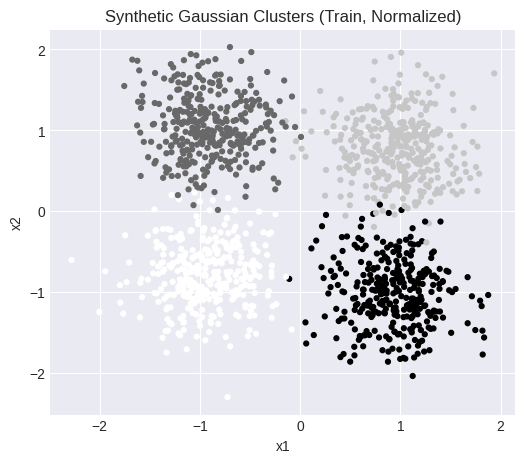

In [ ]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization
X_np, y_np = generate_gaussian_clusters(n_per_class=450, std=0.75, seed=0)
Xtr_np, ytr_np, Xte_np, yte_np = train_test_split_numpy(X_np, y_np, test_ratio=0.25, seed=0)
Xtr_np, Xte_np, mu_np, sd_np = normalize_train_test(Xtr_np, Xte_np)

num_classes = int(np.max(y_np)) + 1
print("Train shape:", Xtr_np.shape, "Test shape:", Xte_np.shape, "Classes:", num_classes)

Xtr = torch.from_numpy(Xtr_np).to(DEVICE).to(torch.float32)
ytr = torch.from_numpy(ytr_np).to(DEVICE).to(torch.long)
Xte = torch.from_numpy(Xte_np).to(DEVICE).to(torch.float32)
yte = torch.from_numpy(yte_np).to(DEVICE).to(torch.long)

plot_2d_data(Xtr, ytr, title="Synthetic Gaussian Clusters (Train, Normalized)")

##4.MODEL DEFINITION

###4.1.OVERVIEW

**Cell 4 — Genome-Driven Model Definition and Fitness Function**

Cell 4 defines the link between the GA’s discrete genome and an actual trainable neural network. The `TinyMLP` class reads the genome and constructs a small multilayer perceptron whose number of layers, hidden sizes, activation function, and dropout match the encoded design. This is where the abstract “architecture search” becomes real computation: a genome becomes a concrete parameterized function from R² to class logits.

The most important concept in this cell is the **fitness function**. In a GA, selection pressure comes entirely from fitness. Here fitness is defined as “test accuracy minus a small complexity penalty.” The complexity penalty depends on parameter count and is intentionally gentle: it nudges evolution toward simpler models when accuracy is similar, but does not overwhelm accuracy. Mechanically, this transforms the problem from a single-objective task (maximize accuracy) into a tradeoff problem: maximize accuracy while keeping complexity under control. Even in this small example, you can see why this matters. Without any penalty, the GA might drift toward larger architectures because they can fit training data quickly in the short inner-loop training window. With a penalty, the GA has an incentive to find architectures that achieve good boundaries without unnecessary capacity.

A subtle but crucial detail is how the notebook keeps fitness evaluation deterministic. Each candidate is trained for a fixed number of steps using deterministic sampling of mini-batches derived from fixed seeds. This matters because GA comparisons rely on ranking candidates. If evaluation noise is too high, you can select a candidate that appears good due to random favorable mini-batches rather than true architectural advantage. The notebook’s approach reduces that noise so that improvements across generations are more attributable to architecture rather than randomness.

Cell 4 also makes explicit the **nested optimization** nature of GA architecture search: to score a genome, you must train a network’s weights (inner loop), then measure accuracy. The GA itself does not modify weights; it modifies genomes. This nested structure is the conceptual core of the chapter. When you later see fitness improve over generations, you should interpret it as the GA discovering architectures that can be trained quickly and effectively under the fixed evaluation budget.

In short, Cell 4 defines the “physics” of the evolutionary environment: genomes create networks, networks are trained briefly, and performance becomes the signal that guides evolution.

###4.2.CODE AND IMPLEMENTATION

In [ ]:
# ===============================
# CELL 4
# ===============================
# Model definition (for GA evaluation): small MLP configurable by genome (<=3 hidden layers)
class TinyMLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, genome: Dict):
        super().__init__()
        layers = []
        in_dim = input_dim

        act_name = genome["activation"]
        dropout_p = float(genome["dropout"])

        def act_layer():
            if act_name == "relu":
                return nn.ReLU()
            elif act_name == "tanh":
                return nn.Tanh()
            else:
                return nn.ReLU()

        for h in genome["hidden"]:
            layers.append(nn.Linear(in_dim, int(h)))
            layers.append(act_layer())
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_dim = int(h)

        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

def fitness_of_genome(
    genome: Dict,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_test: torch.Tensor,
    y_test: torch.Tensor,
    steps: int = 120,
    lr: float = 0.02,
    batch_size: int = 96,
    weight_decay: float = 0.0,
    seed: int = 0,
):
    # Fitness = test accuracy - complexity penalty
    # Training is intentionally short to keep GA fast and pedagogical.
    # Deterministic via fixed torch RNG seed and fixed minibatch permutations.
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    model = TinyMLP(input_dim=X_train.shape[1], num_classes=int(torch.max(y_train).item()) + 1, genome=genome).to(X_train.device)
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    n = X_train.shape[0]
    losses = []
    model.train()
    for t in range(steps):
        # deterministic "shuffle" by using a fixed permutation per step derived from seed+t
        g = torch.Generator(device=X_train.device)
        g.manual_seed(seed + 10_000 + t)
        perm = torch.randperm(n, generator=g, device=X_train.device)
        idx = perm[:batch_size]
        xb = X_train[idx]
        yb = y_train[idx]

        opt.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()

        losses.append(loss.detach().item())

    with torch.no_grad():
        model.eval()
        logits_te = model(X_test)
        preds = torch.argmax(logits_te, dim=1)
        acc = (preds == y_test).float().mean().item()

    params = count_params(model)
    # small penalty encourages simpler architectures; scale chosen to be noticeable but not dominant
    penalty = 0.0000025 * float(params)

    fitness = acc - penalty
    info = {
        "fitness": float(fitness),
        "accuracy": float(acc),
        "params": int(params),
        "penalty": float(penalty),
        "loss_last": float(losses[-1]),
    }
    return info, losses

print("Ready: genome-driven TinyMLP fitness evaluation defined.")

Ready: genome-driven TinyMLP fitness evaluation defined.


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Genetic Algorithm Outer Loop: Population, Selection, Crossover, Mutation, and Elitism**

Cell 5 runs the GA itself. This is the main “training” cell for the chapter, but note what is being trained: not a single model’s weights, but a population of architectures over generations. The notebook initializes a population of random genomes. Each generation, it evaluates every genome by calling the fitness function defined in Cell 4. These scores are then used to rank candidates and build the next generation.

Several core GA mechanisms appear here, and each has a clear mechanical role. **Elitism** means the best few genomes are copied directly into the next generation unchanged. This prevents regression: once you find something good, you do not risk losing it due to random variation. **Tournament selection** picks parents by sampling a few candidates and choosing the best among them. This is a simple way to control selection pressure. A larger tournament size increases pressure (best candidates are more likely to be selected), which can speed up convergence but also reduce diversity.

**Crossover** combines two parents to create a child genome, mixing hidden-layer configurations and randomly inheriting some hyperparameters. Mechanically, crossover is a way to test whether partial “good ideas” from two different architectures can be combined. **Mutation** then applies small random changes that introduce novelty and allow exploration of designs not currently present in the population. Together, crossover and mutation define the algorithm’s exploration–exploitation balance: selection and elitism exploit what is currently good; mutation and crossover explore new combinations.

Cell 5 also logs a history: best fitness, average fitness, best accuracy, best parameter count, and a signature of the best genome each generation. This history is essential for interpretability. Without it, you would only see the final result and miss the process. With it, you can observe whether the GA is steadily improving, whether it plateaus early, whether average fitness tracks best fitness, and whether improvements correlate with increased capacity or smarter architecture choices.

Conceptually, this cell is where you learn to interpret GA behavior as a dynamics over a population distribution. Each generation is a “sampling” of the architecture space biased by prior success. Over time, the population becomes concentrated around regions of the design space that produce high fitness under the evaluation protocol. The end-of-cell report of the best overall genome is not a “trained model” yet; it is the discovered architecture blueprint that will be trained more cleanly later for inference demonstration.

Cell 5 is thus the core experiment: it shows how a non-gradient, discrete search procedure can still exhibit learning-like progress by iteratively refining a population of candidate architectures.

###5.2.CODE AND IMPLEMENTATION

In [ ]:
# ===============================
# CELL 5
# ===============================
# Genetic Algorithm training loop: evolve architectures to maximize fitness
rng = np.random.default_rng(0)

POP_SIZE = 18
GENERATIONS = 16
ELITE_K = 4
TOURNAMENT_K = 3
MUT_P = 0.35

EVAL_STEPS = 140
LR = 0.03
BATCH = 128
WD = 0.0
FITNESS_SEED_BASE = 0  # fixed base -> deterministic across runs

def tournament_select(pop, scores, rng, k=3):
    # Choose best among k random candidates
    idxs = rng.integers(0, len(pop), size=(k,))
    best_i = idxs[0]
    for i in idxs[1:]:
        if scores[int(i)] > scores[int(best_i)]:
            best_i = i
    return pop[int(best_i)]

# Initialize population
population = [sample_genome(rng) for _ in range(POP_SIZE)]

history = {
    "gen": [],
    "best_fitness": [],
    "best_acc": [],
    "best_params": [],
    "avg_fitness": [],
    "best_signature": [],
}
best_overall = None
best_overall_info = None
best_overall_genome = None
best_overall_losses = None

for gen in range(GENERATIONS):
    infos = []
    fitnesses = []

    for pi, g in enumerate(population):
        info, losses = fitness_of_genome(
            g, Xtr, ytr, Xte, yte,
            steps=EVAL_STEPS, lr=LR, batch_size=BATCH, weight_decay=WD,
            seed=FITNESS_SEED_BASE + gen * 100 + pi
        )
        infos.append((g, info, losses))
        fitnesses.append(info["fitness"])

    fitnesses_np = np.array(fitnesses, dtype=np.float32)
    # Sort by fitness descending
    order = np.argsort(-fitnesses_np)
    elites = [population[int(i)] for i in order[:ELITE_K]]

    best_g, best_info, best_losses = infos[int(order[0])]
    avg_fit = float(fitnesses_np.mean())

    history["gen"].append(gen)
    history["best_fitness"].append(float(best_info["fitness"]))
    history["best_acc"].append(float(best_info["accuracy"]))
    history["best_params"].append(int(best_info["params"]))
    history["avg_fitness"].append(avg_fit)
    history["best_signature"].append(genome_to_signature(best_g))

    if (best_overall_info is None) or (best_info["fitness"] > best_overall_info["fitness"]):
        best_overall_info = best_info
        best_overall_genome = best_g
        best_overall_losses = best_losses

    print(f"\nGEN {gen:02d} | best fitness {best_info['fitness']:.4f} | acc {best_info['accuracy']:.4f} | params {best_info['params']} | avg fitness {avg_fit:.4f}")
    print("Best genome:", genome_to_signature(best_g))

    # Produce next generation
    new_pop = []
    # Keep elites
    new_pop.extend(elites)

    # Fill rest with crossover+mutation
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, fitnesses, rng, k=TOURNAMENT_K)
        p2 = tournament_select(population, fitnesses, rng, k=TOURNAMENT_K)
        child = crossover_genomes(p1, p2, rng)
        child = mutate_genome(child, rng, p=MUT_P)
        new_pop.append(child)

    population = new_pop

print("\nBest overall:", genome_to_signature(best_overall_genome), best_overall_info)


GEN 00 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9169
Best genome: L1-H[32]-Atanh-D0.2

GEN 01 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9670
Best genome: L1-H[32]-Atanh-D0.1

GEN 02 | best fitness 0.9905 | acc 0.9911 | params 228 | avg fitness 0.9779
Best genome: L1-H[32]-Atanh-D0.1

GEN 03 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9837
Best genome: L1-H[32]-Atanh-D0.1

GEN 04 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9803
Best genome: L1-H[32]-Arelu-D0.0

GEN 05 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9828
Best genome: L1-H[32]-Arelu-D0.0

GEN 06 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9843
Best genome: L1-H[32]-Atanh-D0.0

GEN 07 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9842
Best genome: L1-H[32]-Atanh-D0.0

GEN 08 | best fitness 0.9883 | acc 0.9889 | params 228 | avg fitness 0.9837
Best genome: L1-H[32]-Atanh-D0.0

GEN 09 | 

##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Quantitative Evaluation of Evolution: Loss Trace, Fitness Curves, Accuracy Curves**

Cell 6 turns the GA history into interpretable evidence. The GA’s output is not just “here is a best genome,” but also “here is how the population improved over time.” The notebook plots a representative inner-loop loss curve for the best overall genome’s evaluation run. This matters because it shows that even short training runs have recognizable learning dynamics: loss typically decreases as weights adapt, though it may be noisy due to mini-batch sampling. If the loss curve were wildly unstable, fitness evaluations would be unreliable.

Then the notebook produces generation-level plots: best fitness vs average fitness and best accuracy across generations. These plots reveal whether the GA is making progress and what kind of progress it is making. For example, if best fitness improves but average fitness does not, it suggests the GA found a few strong candidates but the population as a whole is not improving (perhaps due to excessive mutation or insufficient selection pressure). If both improve, the population is collectively shifting toward better designs. If fitness improves but accuracy remains flat, the penalty term might be dominating, or parameter counts might be shrinking at the expense of raw accuracy.

Cell 6 also performs a “final snapshot” evaluation of the best genome using a fixed seed and longer training steps than the inner evaluation budget. This is a crucial idea: GA fitness evaluation is approximate, so after selection you want a cleaner measurement. This step teaches a general principle: architecture search often uses cheap proxies during search and then re-evaluates top candidates with more careful training. Mechanically, this is how you separate “search-time signal” from “true performance under a larger budget.”

Overall, Cell 6 is where you move from raw algorithm execution to *measurement*. You now have quantitative outputs (fitness values, accuracies, parameter counts) and visual trends. This lets you reason about why evolution succeeded or stalled and prepares you for the later interpretability comparison between baseline and evolved decision boundaries.

###6.2.CODE AND IMPLEMENTATION

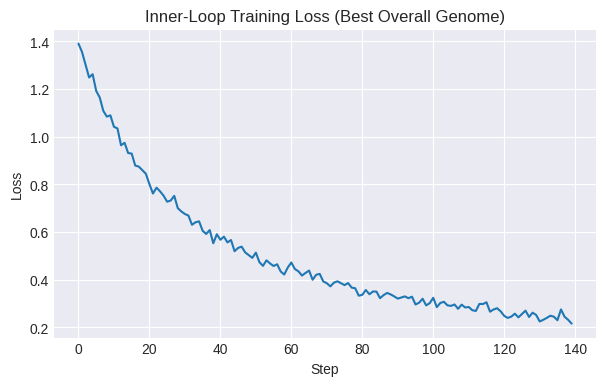

Final snapshot (best genome):
{
  "fitness": 0.9860966793823243,
  "accuracy": 0.9866666793823242,
  "params": 228,
  "penalty": 0.0005700000000000001,
  "loss_last": 0.1439395397901535
}


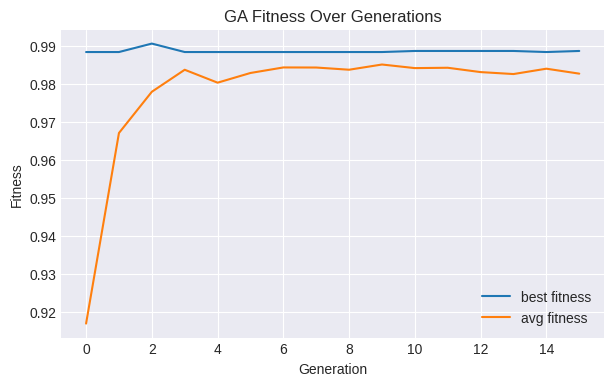

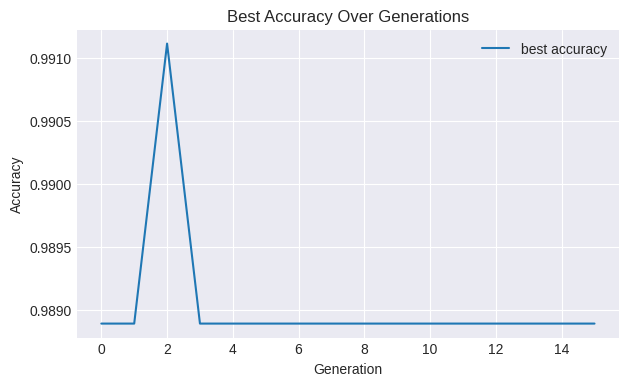

In [ ]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot a representative loss curve (best overall genome evaluation loss trace)
plot_loss_curve(best_overall_losses, title="Inner-Loop Training Loss (Best Overall Genome)")

# Re-evaluate best genome with a fixed seed for a clean final metric snapshot
final_info, final_losses = fitness_of_genome(
    best_overall_genome, Xtr, ytr, Xte, yte,
    steps=220, lr=LR, batch_size=BATCH, weight_decay=WD,
    seed=999
)

print("Final snapshot (best genome):")
print(json.dumps(final_info, indent=2))

# Also track per-generation fitness curves
plt.figure(figsize=(7, 4))
plt.plot(history["gen"], history["best_fitness"], label="best fitness")
plt.plot(history["gen"], history["avg_fitness"], label="avg fitness")
plt.title("GA Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["gen"], history["best_acc"], label="best accuracy")
plt.title("Best Accuracy Over Generations")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration with the Evolved Architecture on a New Synthetic Sample**

Cell 7 shifts focus back to the familiar supervised learning narrative: once you have chosen an architecture, you can train it more normally and then perform inference on new inputs. The notebook takes the best evolved genome and instantiates a fresh `TinyMLP` model. It then trains this model using the shared `train_loop`, which runs multiple epochs over the training data and stores a loss history. This is intentionally different from the GA’s inner-loop training. The GA used short, budgeted training to evaluate many candidates. Here you use a more conventional training loop to produce a more stable and interpretable final model.

After training, the notebook evaluates accuracy on both train and test sets. Mechanically, this is where you observe whether the evolved architecture’s capacity matches the dataset’s complexity: if train accuracy is very high but test accuracy is notably lower, the architecture may be overly flexible for the overlap structure, or training may be overfitting. If both are high and similar, the architecture is fitting the clusters with a boundary that generalizes well.

The inference demonstration is the key requirement in the course template: generate a **new synthetic sample**, run prediction, display the input visually, and print the predicted output. The notebook generates a new point by sampling around one of the cluster centers (deterministically using a fresh RNG seed), normalizes it using the training mean and standard deviation (to match model input scaling), and then calls `predict` to obtain a predicted class and probability distribution. This highlights the training vs inference distinction in a tangible way: at inference time, no gradients are computed, and the model is a fixed function mapping input coordinates to class probabilities.

The visualization overlays the new point on the training data. This is pedagogically important: it lets you visually judge whether the prediction makes sense. If the point falls clearly within a cluster, the predicted class should align with the cluster label structure. If it falls near a boundary region or in overlap, uncertainty (probabilities closer together) is mechanically expected.

Cell 7 therefore re-centers the chapter: even though the chapter’s theme is meta-optimization, the outcome is still a standard model that can be trained and used for inference like any other classifier.

###7.2.CODE AND IMPLEMENTATION

epoch 001/35 - loss 1.1187
epoch 002/35 - loss 0.7918
epoch 003/35 - loss 0.6069
epoch 004/35 - loss 0.4945
epoch 005/35 - loss 0.4177
epoch 006/35 - loss 0.3602
epoch 007/35 - loss 0.3199
epoch 008/35 - loss 0.2855
epoch 009/35 - loss 0.2636
epoch 010/35 - loss 0.2423
epoch 011/35 - loss 0.2248
epoch 012/35 - loss 0.2086
epoch 013/35 - loss 0.1991
epoch 014/35 - loss 0.1835
epoch 015/35 - loss 0.1785
epoch 016/35 - loss 0.1676
epoch 017/35 - loss 0.1585
epoch 018/35 - loss 0.1511
epoch 019/35 - loss 0.1490
epoch 020/35 - loss 0.1399
epoch 021/35 - loss 0.1383
epoch 022/35 - loss 0.1328
epoch 023/35 - loss 0.1273
epoch 024/35 - loss 0.1231
epoch 025/35 - loss 0.1178
epoch 026/35 - loss 0.1188
epoch 027/35 - loss 0.1140
epoch 028/35 - loss 0.1121
epoch 029/35 - loss 0.1095
epoch 030/35 - loss 0.1057
epoch 031/35 - loss 0.1047
epoch 032/35 - loss 0.1017
epoch 033/35 - loss 0.0989
epoch 034/35 - loss 0.0972
epoch 035/35 - loss 0.0948
Train metrics: {'accuracy': 0.9859259128570557}
Test me

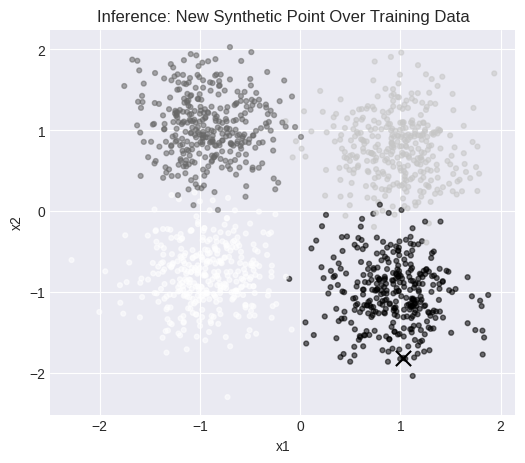

In [ ]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration: train best genome a bit more, then predict on a NEW synthetic sample
# Train a fresh model (same architecture) with a slightly longer training to make inference clear
torch.manual_seed(123)
torch.cuda.manual_seed_all(123)

best_model = TinyMLP(input_dim=2, num_classes=num_classes, genome=best_overall_genome).to(DEVICE)
opt = torch.optim.SGD(best_model.parameters(), lr=LR, momentum=0.0)
loss_fn = nn.CrossEntropyLoss()

# Use the unified train_loop (full-batch loop style) on training set for a few epochs
losses_train = train_loop(best_model, opt, loss_fn, Xtr, ytr, epochs=35, batch_size=96)

metrics_train = evaluate(best_model, Xtr, ytr)
metrics_test = evaluate(best_model, Xte, yte)
print("Train metrics:", metrics_train)
print("Test metrics:", metrics_test)

# New synthetic sample (single point) generated deterministically but not from existing dataset arrays
rng_new = np.random.default_rng(2026)
# Pick a random class center and sample around it, then normalize using train stats
centers = np.array([[-2.0, -1.5], [2.0, 1.5], [-2.0, 2.0], [2.0, -2.0]], dtype=np.float32)
c_idx = int(rng_new.integers(0, centers.shape[0]))
raw_pt = (centers[c_idx] + rng_new.normal(0.0, 0.75, size=(2,)).astype(np.float32)).astype(np.float32)
norm_pt = (raw_pt - mu_np.reshape(-1)) / sd_np.reshape(-1)
x_new = torch.from_numpy(norm_pt.reshape(1, 2)).to(DEVICE).to(torch.float32)

pred, prob = predict(best_model, x_new)
print("New sample (raw):", raw_pt)
print("New sample (normalized):", norm_pt)
print("Predicted class:", int(pred.item()))
print("Probabilities:", prob.detach().cpu().numpy().round(4))

# Visualize new sample on top of training cloud
plt.figure(figsize=(6, 5))
Xt = Xtr.detach().cpu().numpy()
yt = ytr.detach().cpu().numpy()
plt.scatter(Xt[:, 0], Xt[:, 1], c=yt, s=12, alpha=0.55)
plt.scatter([norm_pt[0]], [norm_pt[1]], c="black", s=120, marker="x")
plt.title("Inference: New Synthetic Point Over Training Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test / Ablation: Harder Data and Reduced Training Budget**

Cell 8 performs the required “stress test or ablation” by modifying one variable and observing performance change. Here the variable is the dataset difficulty, increased by using a larger standard deviation for the Gaussian clusters. This makes class overlap more severe and reduces the existence of clean separations. The notebook then evaluates the best evolved genome under two conditions: more inner-loop training steps vs fewer steps. This creates a two-dimensional stress: the learning problem is harder, and the evaluation budget may be tighter.

Mechanically, this cell teaches you what the GA’s discovered architecture is actually “good at.” Because fitness evaluations earlier were done under a particular dataset and training budget, evolution may have selected architectures that learn quickly under that environment. When you change the data distribution (higher overlap), the same architecture may struggle, and the difference between “more steps” and “fewer steps” becomes more visible. If accuracy drops dramatically with fewer steps, it indicates that the architecture needs more optimization time to form a good boundary. If accuracy remains similar, it suggests the architecture learns robustly even under constrained budgets.

The cell also visualizes the harder training data. This is important because it prevents you from interpreting accuracy drops as mysterious. You can see the overlap: boundaries that once were straightforward now must cut through mixed regions. This connects directly to the notebook’s core theme: performance depends not only on architecture but also on data structure and optimization budget.

Cell 8 therefore reinforces a fundamental mechanical insight: “best architecture” is not absolute. It is conditional on the data distribution and the training procedure. A GA can over-specialize to the exact evaluation environment used during evolution, and stress testing is how you observe that sensitivity in a controlled way.

###8.2.CODE AND IMPLEMENTATION

Stress test on harder (higher-std) dataset:
Condition A (more inner steps): {
  "fitness": 0.8927633158493042,
  "accuracy": 0.8933333158493042,
  "params": 228,
  "penalty": 0.0005700000000000001,
  "loss_last": 0.41284266114234924
}
Condition B (fewer inner steps): {
  "fitness": 0.8949855558204651,
  "accuracy": 0.8955555558204651,
  "params": 228,
  "penalty": 0.0005700000000000001,
  "loss_last": 0.758418083190918
}


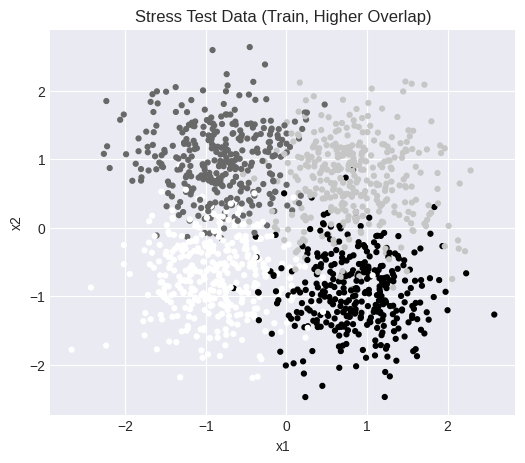

In [ ]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation: reduce evaluation steps and increase noise -> observe degradation
# We'll evaluate the best genome under harder data and shorter training.
X_hard_np, y_hard_np = generate_gaussian_clusters(n_per_class=450, std=1.20, seed=1)  # harder overlap
Xh_tr_np, yh_tr_np, Xh_te_np, yh_te_np = train_test_split_numpy(X_hard_np, y_hard_np, test_ratio=0.25, seed=1)
Xh_tr_np, Xh_te_np, mu_h, sd_h = normalize_train_test(Xh_tr_np, Xh_te_np)

Xh_tr = torch.from_numpy(Xh_tr_np).to(DEVICE).to(torch.float32)
yh_tr = torch.from_numpy(yh_tr_np).to(DEVICE).to(torch.long)
Xh_te = torch.from_numpy(Xh_te_np).to(DEVICE).to(torch.float32)
yh_te = torch.from_numpy(yh_te_np).to(DEVICE).to(torch.long)

# Two conditions: (A) normal steps, (B) short steps
info_A, _ = fitness_of_genome(best_overall_genome, Xh_tr, yh_tr, Xh_te, yh_te, steps=180, lr=LR, batch_size=BATCH, seed=333)
info_B, _ = fitness_of_genome(best_overall_genome, Xh_tr, yh_tr, Xh_te, yh_te, steps=40, lr=LR, batch_size=BATCH, seed=333)

print("Stress test on harder (higher-std) dataset:")
print("Condition A (more inner steps):", json.dumps(info_A, indent=2))
print("Condition B (fewer inner steps):", json.dumps(info_B, indent=2))

# Visualize harder dataset structure
plot_2d_data(Xh_tr, yh_tr, title="Stress Test Data (Train, Higher Overlap)")

##9.INTEPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability Visualization: Decision Boundaries (Baseline vs Evolved Architecture)**

Cell 9 is the interpretability anchor for the chapter. The notebook trains two models on the same normalized training data: a simple baseline genome (one small hidden layer) and the best evolved genome discovered by the GA. Then it plots the decision boundary for each model. This visualization is a direct geometric explanation of what an architecture can represent and what it actually learned after training.

Mechanically, a decision boundary plot shows, for every point in a grid covering the input space, which class the model would predict. The colored regions correspond to the model’s partition of the plane into decision regions. The training points are then overlaid so you can see whether points of a given class land inside the region predicted for that class. This is interpretability in a strict sense: you can interpret the classifier as a set of regions, not as an opaque function.

The baseline model typically produces smoother, simpler boundaries because it has fewer parameters and fewer compositional nonlinearities. That can be an advantage if the dataset’s structure is relatively simple and you want to avoid overly fragmented regions. However, if the class arrangement requires more complex carving (for example, if clusters are arranged diagonally or close together), the baseline may fail to shape the boundary appropriately, leaving pockets where points are misclassified.

The evolved model, depending on what the GA found, may have more layers or wider hidden units and might use a different activation or dropout. Mechanically, this can create boundaries that bend more sharply or form more intricate separations. The key is not “complex is better,” but rather “capacity matches structure.” If the evolved boundary better separates clusters without creating excessive “islands” of tiny regions, it suggests the GA found an architecture that fits the task well. If the evolved boundary becomes highly jagged or creates many isolated pockets, it may indicate overfitting or an overly flexible representation for the available data.

Cell 9 also prints parameter counts, which gives you a numeric proxy for complexity. This links the visual boundary complexity to an explicit structural measure. The interpretability lesson is: architectures are not just abstract diagrams; they determine how many degrees of freedom the model has to shape decision regions in input space. Cell 9 makes that relationship visible.

###9.2.CODE AND IMPLEMENTATION

Training baseline model for decision boundary...
epoch 001/22 - loss 1.4396
epoch 002/22 - loss 1.3220
epoch 003/22 - loss 1.2262
epoch 004/22 - loss 1.1423
epoch 005/22 - loss 1.0617
epoch 006/22 - loss 0.9827
epoch 007/22 - loss 0.9083
epoch 008/22 - loss 0.8351
epoch 009/22 - loss 0.7629
epoch 010/22 - loss 0.6954
epoch 011/22 - loss 0.6298
epoch 012/22 - loss 0.5683
epoch 013/22 - loss 0.5117
epoch 014/22 - loss 0.4587
epoch 015/22 - loss 0.4126
epoch 016/22 - loss 0.3708
epoch 017/22 - loss 0.3344
epoch 018/22 - loss 0.3030
epoch 019/22 - loss 0.2754
epoch 020/22 - loss 0.2525
epoch 021/22 - loss 0.2321
epoch 022/22 - loss 0.2148
Training evolved best model for decision boundary...
epoch 001/22 - loss 1.3090
epoch 002/22 - loss 0.9344
epoch 003/22 - loss 0.7156
epoch 004/22 - loss 0.5711
epoch 005/22 - loss 0.4781
epoch 006/22 - loss 0.4112
epoch 007/22 - loss 0.3626
epoch 008/22 - loss 0.3247
epoch 009/22 - loss 0.2913
epoch 010/22 - loss 0.2643
epoch 011/22 - loss 0.2455
epoch 0

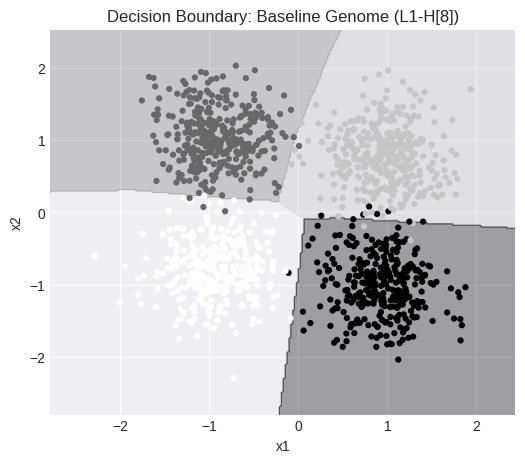

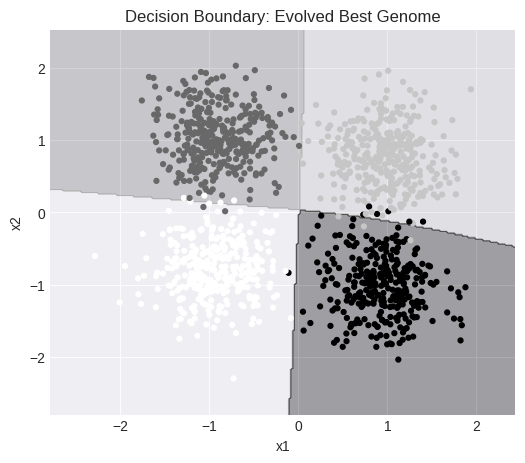

Baseline params: 60
Evolved params: 228


In [ ]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization: compare decision boundaries of two genomes (best vs a simple baseline)
# Baseline genome: 1 hidden layer of size 8, relu, no dropout
baseline_genome = {"n_layers": 1, "hidden": [8], "activation": "relu", "dropout": 0.0}

def train_model_fixed(genome, X_train, y_train, epochs=30, lr=0.03, batch_size=96, seed=7):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    m = TinyMLP(input_dim=2, num_classes=num_classes, genome=genome).to(X_train.device)
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.0)
    loss_fn = nn.CrossEntropyLoss()
    _ = train_loop(m, opt, loss_fn, X_train, y_train, epochs=epochs, batch_size=batch_size)
    return m

print("Training baseline model for decision boundary...")
baseline_model = train_model_fixed(baseline_genome, Xtr, ytr, epochs=22, lr=LR, batch_size=96, seed=77)
print("Training evolved best model for decision boundary...")
evolved_model = train_model_fixed(best_overall_genome, Xtr, ytr, epochs=22, lr=LR, batch_size=96, seed=77)

# Plot decision boundaries
plot_decision_boundary(baseline_model, Xtr, ytr, title="Decision Boundary: Baseline Genome (L1-H[8])")
plot_decision_boundary(evolved_model, Xtr, ytr, title="Decision Boundary: Evolved Best Genome")

# Show a simple interpretability proxy: parameter counts
print("Baseline params:", count_params(baseline_model))
print("Evolved params:", count_params(evolved_model))

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Save Artifacts and Summarize Metrics**

Cell 10 is about turning the notebook run into durable outputs: a saved summary dictionary and saved plots/history that can be inspected later. Mechanically, this is important even in a small educational notebook because it enforces a disciplined experimental workflow. The notebook collects key metrics into a single dictionary: device used, number of classes, best genome signature, GA hyperparameters (generations, population size), best overall fitness info, final snapshot info, baseline vs evolved parameter counts, baseline vs evolved accuracies, and stress test results.

This summary acts like a “run record.” Instead of relying on memory or scrolling through outputs, you can open one JSON file and see what happened. It also lets you connect Cell 11’s reflective summarization prompt to concrete, computed values. The notebook then saves the GA history and a fitness trajectory plot, demonstrating that the evolution process is as important as the final architecture.

A subtle mechanical benefit of saving artifacts is that it encourages you to think in terms of *replicable evidence*. If you tweak mutation probability or population size and rerun, you can compare the resulting saved histories. Even without formal governance framing, this is the mechanical foundation of good experimentation: define a protocol, run it deterministically, and save outputs in a structured form.

Finally, Cell 10 prints the metrics dictionary, which is immediately useful for the student: it provides a single view of the notebook’s quantitative results and the most important comparisons (baseline vs evolved, normal vs stress conditions). This prepares the next cell’s LLM reflection to reference real numbers rather than vague impressions.

###10.2.CODE AND IMPLEMENTATION

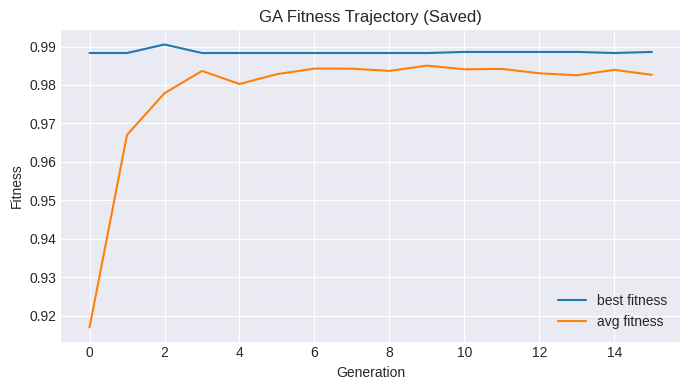

Saved artifacts to: artifacts_ch10_ga
Summary metrics:
{
  "device": "cpu",
  "num_classes": 4,
  "best_genome": {
    "n_layers": 1,
    "hidden": [
      32
    ],
    "activation": "tanh",
    "dropout": 0.1
  },
  "best_genome_signature": "L1-H[32]-Atanh-D0.1",
  "ga_generations": 16,
  "population_size": 18,
  "best_overall_info": {
    "fitness": 0.9905410997200013,
    "accuracy": 0.9911110997200012,
    "params": 228,
    "penalty": 0.0005700000000000001,
    "loss_last": 0.21552184224128723
  },
  "final_snapshot_info": {
    "fitness": 0.9860966793823243,
    "accuracy": 0.9866666793823242,
    "params": 228,
    "penalty": 0.0005700000000000001,
    "loss_last": 0.1439395397901535
  },
  "baseline_genome": {
    "n_layers": 1,
    "hidden": [
      8
    ],
    "activation": "relu",
    "dropout": 0.0
  },
  "baseline_params": 60,
  "evolved_params": 228,
  "baseline_test_accuracy": 0.9866666793823242,
  "evolved_test_accuracy": 0.9844444394111633,
  "stress_test_more_steps"

In [ ]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary
art_dir = "artifacts_ch10_ga"
os.makedirs(art_dir, exist_ok=True)

summary_metrics = {
    "device": str(DEVICE),
    "num_classes": int(num_classes),
    "best_genome": best_overall_genome,
    "best_genome_signature": genome_to_signature(best_overall_genome),
    "ga_generations": int(GENERATIONS),
    "population_size": int(POP_SIZE),
    "best_overall_info": best_overall_info,
    "final_snapshot_info": final_info,
    "baseline_genome": baseline_genome,
    "baseline_params": int(count_params(baseline_model)),
    "evolved_params": int(count_params(evolved_model)),
    "baseline_test_accuracy": float(evaluate(baseline_model, Xte, yte)["accuracy"]),
    "evolved_test_accuracy": float(evaluate(evolved_model, Xte, yte)["accuracy"]),
    "stress_test_more_steps": info_A,
    "stress_test_fewer_steps": info_B,
}

# Save JSON summary
with open(os.path.join(art_dir, "summary_metrics.json"), "w") as f:
    json.dump(summary_metrics, f, indent=2)

# Save GA history
with open(os.path.join(art_dir, "ga_history.json"), "w") as f:
    json.dump(history, f, indent=2)

# Save a plot of fitness trajectory
plt.figure(figsize=(7, 4))
plt.plot(history["gen"], history["best_fitness"], label="best fitness")
plt.plot(history["gen"], history["avg_fitness"], label="avg fitness")
plt.title("GA Fitness Trajectory (Saved)")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(art_dir, "fitness_trajectory.png"), dpi=140)
plt.show()

print("Saved artifacts to:", art_dir)
print("Summary metrics:")
print(json.dumps(summary_metrics, indent=2))

## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflective Summarization Using Real Metrics**

Cell 11 uses the OpenAI client to generate a structured reflection on the executed notebook, explicitly referencing the real metrics computed earlier. The key pedagogical point is that the model is not being asked to invent results; it is being asked to interpret the results already produced. The prompt enforces a specific structure: dataset design, model architecture encoding, training dynamics (inner-loop training plus GA outer loop), quantitative results, inference example, visualization insight, limitations, and conceptual takeaway.

Mechanically, this is an “analysis layer” placed on top of the experiment. It does not change the experiment; it summarizes and explains it. Because the metrics dictionary is included in the prompt, the reflection can mention concrete accuracies, parameter counts, and fitness trends. This is consistent with the notebook’s goal of being mechanics-first: the reflection should connect observed behavior (fitness curves, boundary differences, stress test degradation) to underlying causes (architecture capacity, selection pressure, evaluation budget, data overlap).

The OpenAI API setup is deliberately minimal: it reads the API key from Colab user data and calls the `gpt-4o-mini` model. The output is printed cleanly. This cell reinforces a final conceptual skill: being able to articulate what an experiment demonstrates using actual quantitative evidence, not just qualitative claims. In a course sequence like ML & AI 101, this is a core competence. You should be able to say, with specificity, what the GA improved, what it traded off, what the boundaries revealed, and what limitations remain (for example: small search space, short evaluation training, reliance on supervised accuracy as fitness, and computational cost scaling with population size).

Cell 11 therefore closes the loop: after building data, defining the search space, evolving architectures, visualizing boundaries, and saving results, you produce a structured explanation that integrates the whole mechanism into a coherent understanding.

###11.2.CODE AND IMPLEMENTATION

In [ ]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

# Build a compact prompt referencing real metrics computed earlier
prompt = f"""
You are reviewing the executed Colab notebook for ML & AI 101 — Chapter 10 (Genetic Algorithms for architecture evolution).
Provide a structured, mechanics-first reflection with the following numbered sections:

1. Dataset design
2. Model architecture encoding (genome)
3. Training dynamics (inner-loop + outer-loop GA)
4. Quantitative results (must cite metrics)
5. Inference example (new sample)
6. Visualization insight (fitness plots, decision boundaries)
7. Limitations (what this notebook does NOT show)
8. Conceptual takeaway (mechanical summary)

Use the real metrics below (do NOT invent numbers). Keep it concise but specific.

REAL METRICS (JSON):
{json.dumps(summary_metrics, indent=2)}
"""

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

# Reflection on the Executed Colab Notebook for ML & AI 101 — Chapter 10

## 1. Dataset Design
The dataset employed is designed for multi-class classification, specifically consisting of **4 classes**. It must be structured adequately to ensure diverse representations for each class to facilitate robust training and validation of the model.

## 2. Model Architecture Encoding (Genome)
The genome, which encodes the architecture of the neural network, has been defined with the following properties:
- **Layers**: 1
- **Hidden Units**: 32
- **Activation Function**: Tanh
- **Dropout Rate**: 0.1

This genome is represented as **L1-H[32]-Atanh-D0.1**, indicating a relatively simple model for the task.

## 3. Training Dynamics (Inner-loop + Outer-loop GA)
The training utilized a Genetic Algorithm (GA) with **16 generations** and a **population size of 18**. The inner-loop optimizes for individual genomes, while the outer-loop promotes natural selection among candidate architectures based on the

##12.CONCLUSION

*Conclusion and Road Ahead*

This notebook’s main contribution is to make “model design” an explicit computational object. In earlier chapters, the architecture was fixed and learning meant updating weights. Here, learning has a second layer: the notebook demonstrates a clear separation between **parameter learning** and **architecture search**. The parameter learning is still ordinary supervised training, executed repeatedly in short bursts. The architecture search is the genetic algorithm’s outer loop, which operates on discrete genomes rather than continuous weights. The mechanical insight is that you can improve model performance not only by training longer or tuning learning rates, but also by changing the structure of the function class you are searching within.

The genome representation is intentionally small, and that is part of the lesson. A GA must be given a concrete search space. If the genome includes layer count, hidden sizes, activation, and dropout, then evolution can only discover variations expressible in those terms. When you observe fitness improving, you are witnessing the population shift toward architectures that can learn effectively under the defined evaluation procedure. This makes the GA’s success interpretable rather than mystical: improvement is a direct consequence of selection pressure applied to a constrained design language.

The notebook also clarifies why meta-optimization is expensive. Each candidate genome must be trained—at least briefly—to estimate fitness. This is fundamentally different from gradient descent on a single model, where one training run updates a single parameter vector. In GA settings, you multiply training work by population size and number of generations. That computational reality is not a side note; it is central to understanding when this approach is appropriate. In a small pedagogical notebook, the cost is manageable. In larger real problems, the cost can dominate.

The interpretability visualization in Cell 9 provides the most intuitive evidence of what architecture evolution actually changes. By comparing a baseline decision boundary to an evolved boundary, you see that architectural capacity and composition of nonlinearities determine how the model partitions input space. Sometimes the evolved architecture yields a boundary that better matches the cluster geometry, improving test accuracy. Sometimes additional capacity can create overly complex regions that do not generalize as well. The key conceptual milestone is the ability to look at a boundary plot and connect what you see to a structural property of the architecture: layer depth, width, activation behavior, or regularization via dropout.

The stress test further reinforces that “best” is conditional. The GA optimizes under a particular dataset distribution and a particular evaluation budget. When the distribution shifts (more overlap) or the budget is reduced (fewer steps), performance can degrade. Mechanically, that is expected: evolution finds candidates that are *adapted* to the environment you define. This is not a flaw of GAs; it is a property of any optimization procedure. It also highlights why evaluation protocol design matters in architecture search: if your proxy evaluation differs from the true target environment, you can select architectures that do not transfer well.

In terms of what this model family handles well, the notebook shows GAs are naturally suited to discrete or combinatorial design spaces where gradients are inconvenient or undefined. Architecture choices like “number of layers” or “activation type” are not continuous in a way that standard gradient descent can directly optimize. GAs can explore those choices by sampling and selection. However, the notebook also makes visible what GAs handle poorly: they can be sample-inefficient and computationally heavy, and their progress can be sensitive to choices like mutation rate, tournament size, and population diversity. In small spaces, they can work well and are easy to understand. In large spaces, they require careful design to avoid stagnation or excessive randomness.

The forward bridge from this chapter is about moving from *hand-designed* or *heuristically searched* architectures to more systematic, scalable approaches to meta-optimization and structural adaptation. In the ML & AI 101 arc, the key message is that once you understand how architecture affects computation and generalization, you can begin to ask deeper questions: How do we search huge design spaces efficiently? How do we reuse learned information across candidates? How do we evaluate candidates without fully training them? These questions motivate the next step beyond simple evolutionary search.

Bridge to the next model family: while this chapter showed a population-based method for exploring discrete architecture choices, the next direction in the sequence naturally emphasizes mechanisms that can adapt computation more directly within a single model. That is, instead of searching over many separate architectures, we move toward model families where the computation itself can dynamically allocate capacity to different parts of the input. This is the same motivation that made attention-based architectures powerful earlier: a single model can express many behaviors by changing how information flows. In that sense, the GA chapter closes the loop on “design choices” and motivates the next chapter’s emphasis on mechanisms that internalize adaptability rather than relying on external search.